https://www.kaggle.com/code/mohammedmokhtar77/customer-shopping-trends-dataset
https://www.xiaohongshu.com/explore/691195420000000005031ea2?app_platform=ios&app_version=8.66&share_from_user_hidden=true&xsec_source=app_share&type=normal&xsec_token=CBpXz-48LlSYHOWN1fb6xlhxiD9xvCMYD67bh4kjRi6Sc=&author_share=1&xhsshare=CopyLink&shareRedId=ODo2MEY6SUo2NzUyOTgwNjg8OTg6RjhP&apptime=1762912162&share_id=68a222cf0d7c488d8c686433f977ebc7

用户消费行为与偏好分析
numpy pandas matplotlib
一、分析目的
通过对客户购物行为数据进行多维度分析,旨在深入理解消费者画像特征、产品偏好、购买习惯及支付方式等关键因素,挖掘不同用户群体的行为差异与潜在规律。最终为精准营销策略制定、产品品类优化、库存管理以及用户忠诚度提升提供数据驱动的决策支持,进一步提升客户体验与商业效益。


二、数据概览
数据集:
客户购物偏好数据集_readme.md
shopping_trends.csv

In [ ]:
#导入库
import numpy             as np    # lumPy库,用于科学计算
import pandas            as pd    # 导入Pandas库,用于数据处理和分析
import matplotlib.pyplot as plt   #导入Matplotlib的pyplot模块,用于绘图
import seaborn           as sns   # Seaborn库,基于Matplotlib的统计可视化库
import datetime                   # datetime库,用于处理日期和时间:
import warnings                   #  warmings库,用于控制警告信息
warnings.filterwarnings('ignore') # 忽略所有警告信息,避免输出不必要的警告

%matplotlib inline  #JupyterLab魔法命令,使图表直接显示在笔记本中

# #设置Matplotlib的pyplot模块默认字体为需体(Sintet),以支持中文显示
plt.rcParams['font.sans-serif'] = 'SimHei'
# 数据读取
# data= pd.read_excel('D:\文档\工作、简历、作品合集、数据集\shopping trends.xlsx')
data= pd.read_csv("C:/Users/zhen-/.cache/kagglehub/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/versions/2/shopping_trends_updated.csv")
data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [ ]:
data.info()  *  check the data type of each column 尤其是有没有缺失值

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   object 
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
data['Customer ID'] = data['Customer ID'].astype(object)
print(data['Customer ID'].dtype)
print(data['Customer ID'].head())

object
0    1
1    2
2    3
3    4
4    5
Name: Customer ID, dtype: object


检测有无重复值

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
print(data.duplicated().sum())

0


只保留重复值中的第一个值，其余的重复值全部删除

In [9]:
data.drop_duplicates(keep = 'first', inplace=True)

In [10]:
data.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


有一些异常需要依据常识，比如消费金额不能为负数等等，不能为零，不能为空

四、分析维度
分析维度围绕以下六大核心方向展开:
1. 消费者画像分析,包括年龄区间与购买力群体特征、性别差异与消费水平对比,以及高消费州/地区分布与地域偏好;
2. 产品与品类分析,涵盖热门商品类别、品类平均消费金额、颜色偏好以及季节性销售波动;
3. 购买行为分析,聚焦客单价分布、折扣与促销码的使用行为及其对消费金额的影响,并比较订阅用户与非订阅用户的消费差异;
4. 支付与配送偏好分析,包括常用支付方式、配送类型偏好,以及配送方式与消费金额、购买频次之间的关联;
5. 复购与忠诚度分析,涉及历史购买次数分布、购买频率划分,并挖掘高复购用户的人口属性与行为特征;
6. 用户反馈分析,围绕评分分布展开,探索高/低分订单的商品与品类共性,以及评分与消费金额、折扣使用等因素的相关性。

In [11]:
print("年龄描述性统计:")
print(data['Age'].describe())

年龄描述性统计:
count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


In [15]:
bins = [17, 25, 35, 45, 55, 65,70]

labels = ['18-25岁','26-35岁', '36-45岁', '46-55岁', '56-65岁', '65岁以上'] 
data['Age Group'] = pd.cut( data['Age'], bins = bins, labels =labels, right=True)
print(data['Age Group'].value_counts())
print(data['Age Group'])

Age Group
46-55岁    753
56-65岁    750
26-35岁    742
36-45岁    729
18-25岁    571
65岁以上     355
Name: count, dtype: int64
0       46-55岁
1       18-25岁
2       46-55岁
3       18-25岁
4       36-45岁
         ...  
3895    36-45岁
3896    46-55岁
3897    46-55岁
3898    36-45岁
3899    46-55岁
Name: Age Group, Length: 3900, dtype: category
Categories (6, object): ['18-25岁' < '26-35岁' < '36-45岁' < '46-55岁' < '56-65岁' < '65岁以上']


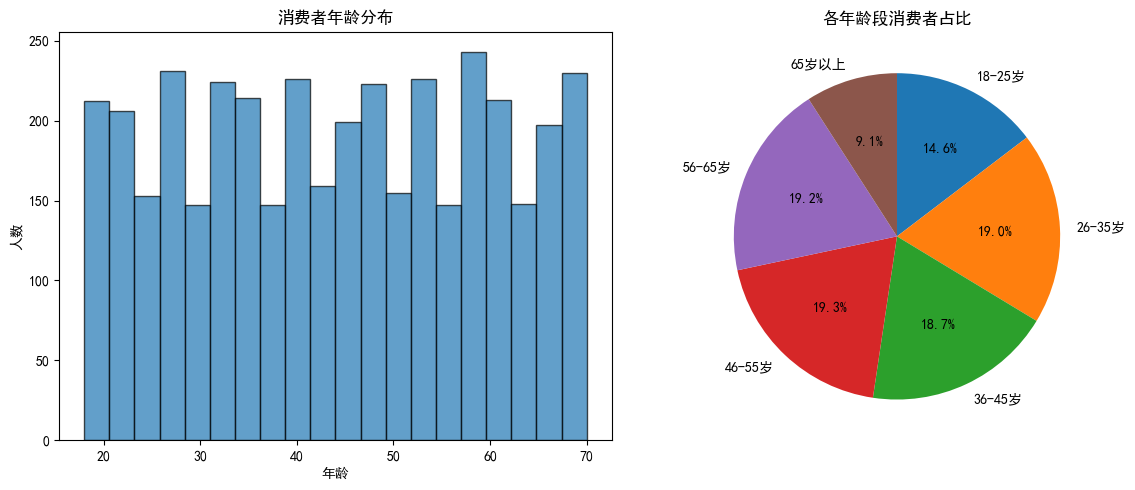

In [18]:
#绘制年齡分布图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['Age'], bins=20, edgecolor='black', alpha=0.7)

plt.title('消费者年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')

plt.subplot(1, 2, 2)
age_group_counts = data['Age Group'].value_counts().sort_index()


plt.pie( age_group_counts, labels = age_group_counts.index, autopct='%1.1f%%',startangle=90,counterclock=False)  
# counter clockwise as default, 0 degree start angle from x-axis point to right, like regular unit circle
plt.title('各年龄段消费者占比')
plt.tight_layout()
plt.show()


In [19]:
#各年龄段消費能力分析
age_group_analysis = data.groupby('Age Group')['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
age_group_analysis.columns = ['平均消费金额','消费金额中位数','人数']
print("\n各年龄段消费能力分析:")
print(age_group_analysis)


各年龄段消费能力分析:
           平均消费金额  消费金额中位数   人数
Age Group                      
18-25岁      60.65     62.0  571
26-35岁      59.76     60.0  742
36-45岁      59.31     59.0  729
46-55岁      60.58     62.0  753
56-65岁      59.14     58.5  750
65岁以上       58.88     59.0  355


In [20]:
#v 男女比例分析
gender_counts = data['Gender'].value_counts()
gender_ratio = gender_counts ['Male']/gender_counts['Female']
print (f"男女比例:{gender_ratio:.2f}:1")

男女比例:2.12:1


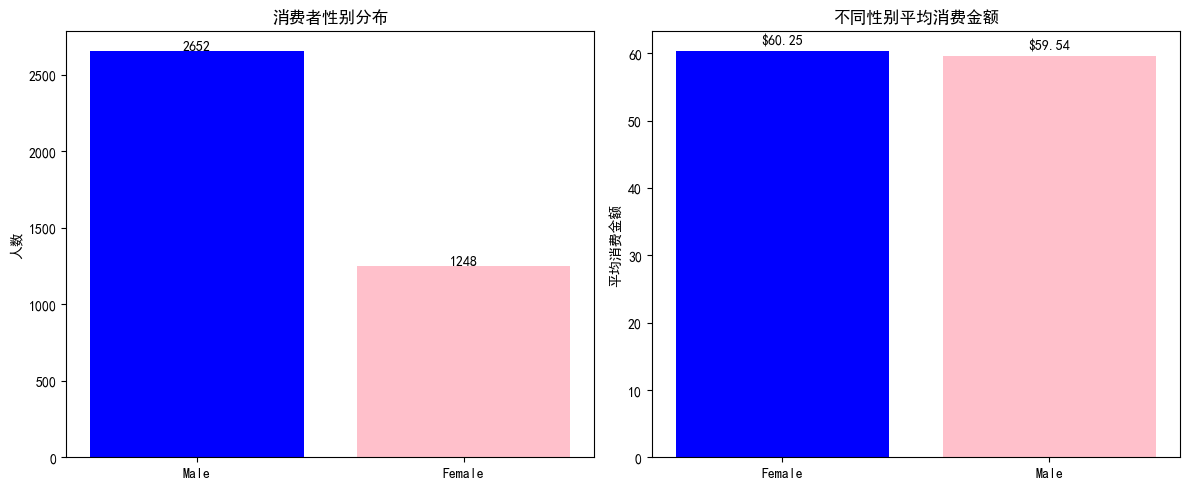

In [24]:
#绘制性到分布图
plt.figure(figsize=(12, 5))

#子图1:性别人数对比
plt.subplot(1, 2, 1)
plt.bar (gender_counts.index, gender_counts.values, color=['blue', 'pink']) 
plt.title('消费者性别分布')
plt.ylabel('人数')

#在柱状图上添加数值标签
for i, v in enumerate (gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center')

#子图2:性别消费金配对比
plt.subplot(1, 2, 2)
gender_amount = data.groupby('Gender')['Purchase Amount (USD)'].mean()
plt.bar(gender_amount.index, gender_amount.values, color=['blue', 'pink'])
plt.title('不同性别平均消费金额')
plt.ylabel('平均消费金额')

#在柱状图上添加数值标签
for i, v in enumerate (gender_amount.values): 
    plt.text(i, v +1, f'${v:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
#性别消费差异统计检验
from scipy import stats # <<<<<<<======================================================

male_amounts   = data[data['Gender'] == 'Male']['Purchase Amount (USD)']
female_amounts = data[data['Gender'] == 'Female']['Purchase Amount (USD)']

t_stat, p_value = stats.ttest_ind(male_amounts, female_amounts) # <<<<<<<======================================================

print(f"\n性别消费差异T检验:t统计量={t_stat:.3f}, p值={p_value:.3f}")

if p_value < 0.05:
    print("不同性别消费金额存在显著差异")
else: 
    print("不同性别消费金额无显著差异")


性别消费差异T检验:t统计量=-0.877, p值=0.381
不同性别消费金额无显著差异


In [26]:
# 各地区消费情况分析
region_analysis = data.groupby ('Location').agg({ 
    'Purchase Amount (USD)': ['sum', 'mean', 'count'],'Age': 'mean' }).round(2)

region_analysis.columns = ['消费总额','平均消费金额','消费者人数','平均年龄']

region_analysis = region_analysis.sort_values('消费总额',ascending=False)
print("各地区消费情况分析:")
print(region_analysis)

各地区消费情况分析:
                消费总额  平均消费金额  消费者人数   平均年龄
Location                                  
Montana         5784   60.25     96  43.82
Illinois        5617   61.05     92  43.28
California      5605   59.00     95  42.66
Idaho           5587   60.08     93  43.30
Nevada          5514   63.38     87  43.61
Alabama         5261   59.11     89  44.31
New York        5257   60.43     87  43.93
North Dakota    5220   62.89     83  43.77
West Virginia   5174   63.88     81  42.54
Nebraska        5172   59.45     87  42.67
New Mexico      5014   61.90     81  44.02
Minnesota       4977   56.56     88  45.48
Pennsylvania    4926   66.57     74  42.97
Mississippi     4883   61.04     80  43.26
Alaska          4867   67.60     72  43.00
Vermont         4860   57.18     85  42.60
Louisiana       4848   57.71     84  48.15
Virginia        4842   62.88     77  41.61
Arkansas        4828   61.11     79  44.10
Maryland        4795   55.76     86  46.90
Tennessee       4772   61.97     77  44.05


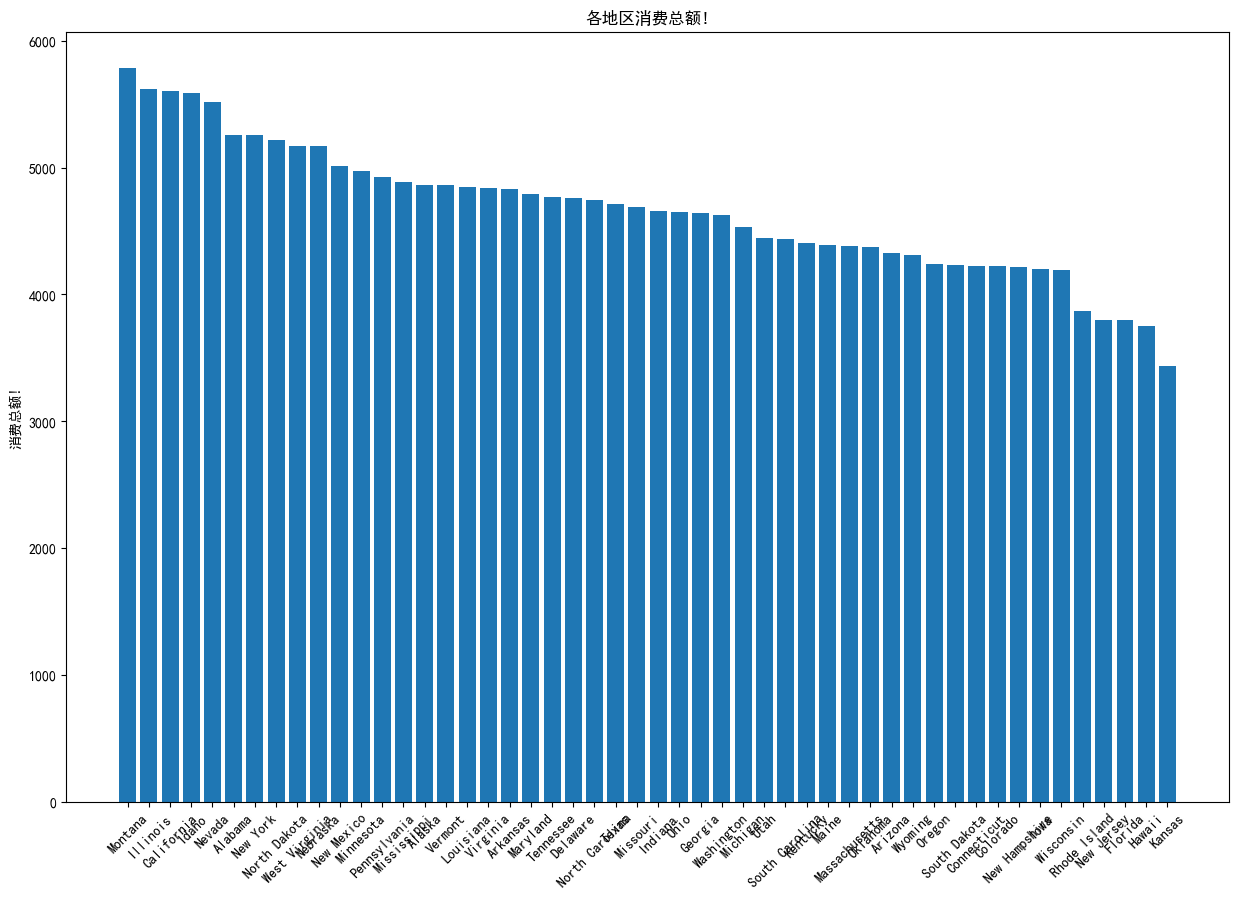

In [29]:
#绘制各地区消费总额
plt.figure(figsize=(15, 10))
region_total = data.groupby('Location') ['Purchase Amount (USD)'].sum().sort_values(ascending=False)

plt.bar(region_total.index, region_total.values)
plt.title('各地区消费总额!')
plt.xticks(rotation=45)
plt.ylabel('消费总额!'); 
# plt.tight_layout()
# plt.show()

In [30]:
# 地域選好分析计算各地区消费占比
total_consumption = data['Purchase Amount (USD)'].sum()
region_analysis['消费占比'] = (region_analysis['消费总额'] / total_consumption * 100).round(2)
region_analysis ['人数占比'] = (region_analysis['消费者人数'] / len(data) *  100).round(2)
print("\n各地区消费占比分析:")
print(region_analysis [['消费占比','人数占比']])


各地区消费占比分析:
                消费占比  人数占比
Location                  
Montana         2.48  2.46
Illinois        2.41  2.36
California      2.40  2.44
Idaho           2.40  2.38
Nevada          2.37  2.23
Alabama         2.26  2.28
New York        2.26  2.23
North Dakota    2.24  2.13
West Virginia   2.22  2.08
Nebraska        2.22  2.23
New Mexico      2.15  2.08
Minnesota       2.14  2.26
Pennsylvania    2.11  1.90
Mississippi     2.09  2.05
Alaska          2.09  1.85
Vermont         2.09  2.18
Louisiana       2.08  2.15
Virginia        2.08  1.97
Arkansas        2.07  2.03
Maryland        2.06  2.21
Tennessee       2.05  1.97
Delaware        2.04  2.21
North Carolina  2.03  2.00
Texas           2.02  1.97
Missouri        2.01  2.08
Indiana         2.00  2.03
Ohio            1.99  1.97
Georgia         1.99  2.03
Washington      1.98  1.87
Michigan        1.94  1.87
Utah            1.91  1.82
South Carolina  1.90  1.95
Kentucky        1.89  2.03
Maine           1.88  1.97
Massachusetts   

In [31]:
#计算消费指数(人均消费相对于平均水平的比值)
overall_avg_spending = data['Purchase Amount (USD)'].mean()
region_analysis['消费指数'] = (region_analysis['平均消费金额']/overall_avg_spending).round(2)

print("\n各地区消费指数(1=平均水平):")
print(region_analysis['消费指数'].sort_values (ascending = False)) 


各地区消费指数(1=平均水平):
Location
Alaska            1.13
Pennsylvania      1.11
Arizona           1.11
West Virginia     1.07
Washington        1.06
Nevada            1.06
North Dakota      1.05
Utah              1.05
Virginia          1.05
New Mexico        1.04
Tennessee         1.04
Michigan          1.04
Rhode Island      1.03
Texas             1.02
Arkansas          1.02
Illinois          1.02
Mississippi       1.02
Massachusetts     1.02
North Carolina    1.02
Wyoming           1.02
Iowa              1.02
Montana           1.01
South Dakota      1.01
Ohio              1.01
New York          1.01
Idaho             1.01
Alabama           0.99
California        0.99
Indiana           0.99
Nebraska          0.99
New Hampshire     0.99
Georgia           0.98
Oklahoma          0.98
South Carolina    0.98
Missouri          0.97
Hawaii            0.97
Louisiana         0.97
Vermont           0.96
Oregon            0.96
Minnesota         0.95
New Jersey        0.95
Maine             0.95
Wiscons

消费者画像综合分析
* 主要消费者年龄段:46-55岁
* 该年龄段特点:人数占比19.3%
* 性别分布:男性2652人,女性1248人,比例2.12:1
* 消费最高的地区: Montana,占总消费2.48%

In [34]:
print("消费者画像综合分析")
print("="* 158)

# 1.主要发现一年齡
dominant_age_group = age_group_analysis ['人数'].idxmax()

print(f"1.主要消费者年龄段:{dominant_age_group}")
print(f" 该年龄段特点:人数占比{age_group_counts[dominant_age_group] /  len(data)*100:.1f}%")

# 2.主要发现一性别
print(f"2、性别分布:男性{gender_counts['Male']}人, 女性{gender_counts['Female']} 人,比例{gender_ratio:.2f}:1")

if p_value < 0.05:
    higher_spender = "女性" if female_amounts.mean() > male_amounts.mean() else "男性" 
    print(f" {higher_spender}平均消费金额较高,差异显著(p={p_value:.3f})")

# 3.主要发现-地域
top_region = region_total.index[0]
print(f"3.消费最高的地区:{top_region}, 占总消費 { region_analysis.loc[top_region, '消费占比'] }%") 
# 注意双引号内不要再次使用双引号， 会导致string 格式错误 <<<==============================

# 4、消费指数最高的地区
highest_index_region = region_analysis['消费指数'].idxmax()
print(f"4.消费力最强的地区:{highest_index_region},消费指数 {region_analysis.loc[highest_index_region, '消费指数']}")


消费者画像综合分析
1.主要消费者年龄段:46-55岁
 该年龄段特点:人数占比19.3%
2、性别分布:男性2652人, 女性1248 人,比例2.12:1
3.消费最高的地区:Montana, 占总消費 2.48%
4.消费力最强的地区:Alaska,消费指数 1.13


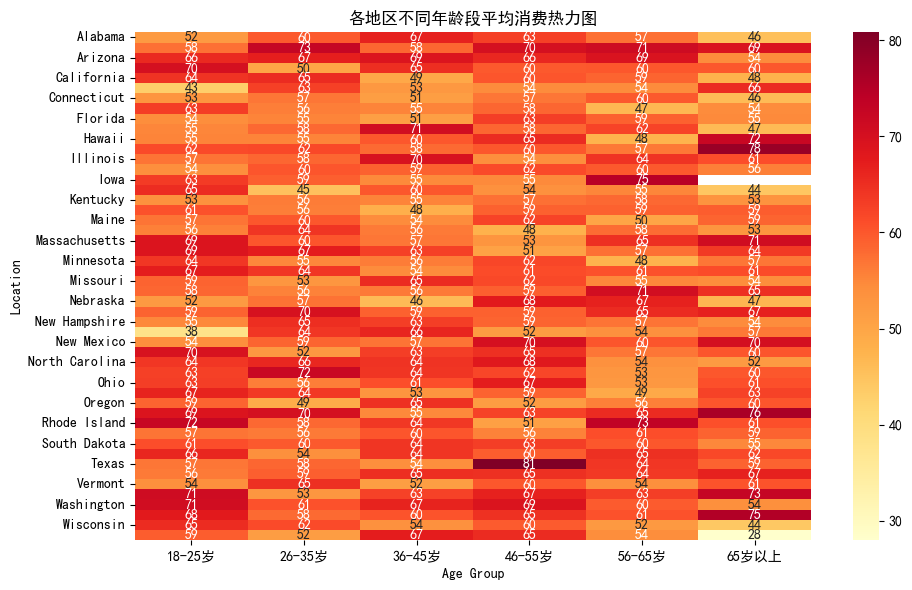

In [35]:
# 绘制综合热力图展示地区、年龄和消费的关系
plt.figure(figsize=(10, 6))
region_age_pivot = pd.pivot_table(data, values = 'Purchase Amount (USD)', index='Location', columns='Age Group', aggfunc='mean')
sns.heatmap(region_age_pivot, annot= True, fmt= '.0f', cmap='YlOrRd')

plt.title('各地区不同年龄段平均消费热力图')
plt.tight_layout()
plt.show() ;

In [36]:
dominant_age_group

'46-55岁'

In [37]:
# 基于分析结果提出建议
print("\n营销建议:")
print("1.目标人群定位:")
print(f" 重点针对{dominant_age_group}年龄段消费者进行营销")

if p_value < 0.05:
    higher_spender = "女性" if female_amounts.mean()> male_amounts.mean() else "男性" 
    print(f" {higher_spender} 平均消费金额较高,差异显著(p={p_value:.3f}), 可设计针对性产品")

print("\n2.地域策略:")

print(f" - 巩固{top_region}市场领先地位,加大投入")
print(f" - 重点关注{highest_index_region}等高消费力地区")
print(f" - 开发消费指数较低但人口基数大的地区市场 ")

print("\n3.产品与营销策略:")
print(" 根据不同地区消费者年龄特点设计差异化产品")
print(" 考虑地区文化偏好设计营销活动")
print(" 针对高消费群体推出高端产品线") ;


营销建议:
1.目标人群定位:
 重点针对46-55岁年龄段消费者进行营销

2.地域策略:
 - 巩固Montana市场领先地位,加大投入
 - 重点关注Alaska等高消费力地区
 - 开发消费指数较低但人口基数大的地区市场 

3.产品与营销策略:
 根据不同地区消费者年龄特点设计差异化产品
 考虑地区文化偏好设计营销活动
 针对高消费群体推出高端产品线


In [39]:
print("商品类别分析:")
print("="*50)
# 按类别统计购买次数
category_counts = data['Category'].value_counts()
print("\n各品类购买次数:")
print(category_counts)
# 按类别统计总销售额
category_sales = data.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
print("\n各品类总销售额:")
print(category_sales.round(2))

商品类别分析:

各品类购买次数:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

各品类总销售额:
Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


In [41]:
#计算品类占比
total_sales = data['Purchase Amount (USD)'].sum()
category_share = (category_sales / total_sales * 100).round(2)
print("\n各品类销售额占比:")
for category, share in category_share.items():
    print (f" (category):   {share}%") 



各品类销售额占比:
 (category):   44.73%
 (category):   31.83%
 (category):   15.49%
 (category):   7.95%


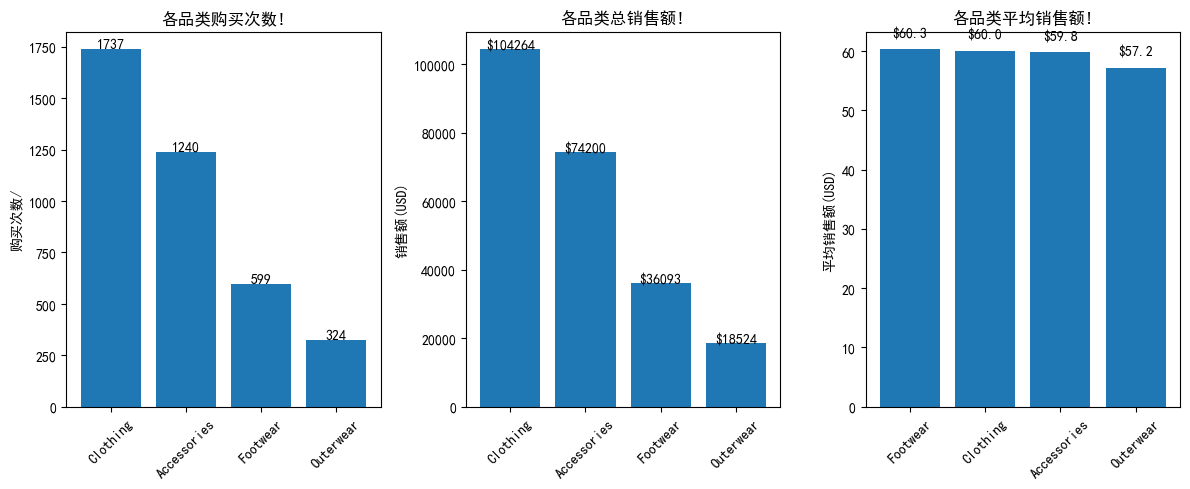

In [42]:
#绘制品类数据图
plt.figure(figsize=(12, 5))

#子图1:各品类购买次数
plt.subplot(1, 3, 1)
plt.bar(category_counts.index, category_counts.values)
plt.title('各品类购买次数!')
plt.xticks (rotation=45)
plt.ylabel('购买次数/')

#在柱状图上添加数值标签
for i, v in enumerate (category_counts.values):
    plt.text(i, v+5, str(v), ha='center')

#子图2:各品类总销售额
plt.subplot(1, 3, 2)
plt.bar(category_sales.index, category_sales.values)
plt.title('各品类总销售额!')
plt.xticks (rotation=45)
plt.ylabel('销售额(USD)')

#在柱状图上添加数值标签
for i, v in enumerate (category_sales.values):
    plt.text(i, v+20, f'${v:.0f}', ha='center')

#子图3:各品类平均销售额
category_avg_sales = data.groupby('Category') ['Purchase Amount (USD)'].mean().sort_values(ascending=False)
plt.subplot(1, 3, 3)
plt.bar(category_avg_sales.index, category_avg_sales.values)
plt.title('各品类平均销售额!')
plt.xticks(rotation=45)
plt.ylabel('平均销售额(USD)')

#在柱状图上添加数道标签
for i, v in enumerate (category_avg_sales.values):
    plt.text(i, v+2, f'${v:.1f}', ha='center')
plt.tight_layout()
plt.show()

In [43]:
print("\n颜色偏好分析:")
print("=" * 50)

#按颜色玩计购买次数
color_counts = data['Color'].value_counts()
print("\n各颜色购买次数:")
print(color_counts)

#按照色统计平均销售额 # 第一个是下面要用，我补上了
#color_counts.values = data.groupby('Color') ["Purchase Amount (USD)"].sum().sort_values(ascending=False)
color_avg_sales     = data.groupby('Color') ["Purchase Amount (USD)"].mean().sort_values(ascending=False)
print("\n各顏色平均销售额:")
print(color_avg_sales.round(2))


颜色偏好分析:

各颜色购买次数:
Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Cyan         166
Violet       166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Blue         152
Magenta      152
Purple       151
Peach        149
Red          148
Beige        147
Indigo       147
Lavender     147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64

各顏色平均销售额:
Color
Green        65.70
White        62.64
Gray         62.49
Cyan         61.89
Violet       61.72
Gold         61.01
Orange       60.89
Teal         60.81
Charcoal     60.63
Pink         60.59
Beige        60.41
Purple       60.01
Maroon       59.53
Red          59.32
Yellow       59.24
Peach        59.19
Lavender     59.13
Brown        59.06
Black        58.40
Olive        58.15
Magenta      57.13
Blue         56.95
Silver       56.83
Indigo       56.25
Turquoise    55.61
Name: Purchase Amount (USD), dty

In [44]:
print(color_counts.values)

[177 174 173 172 169 167 166 166 159 158 154 153 153 152 152 151 149 148
 147 147 147 145 142 141 138]


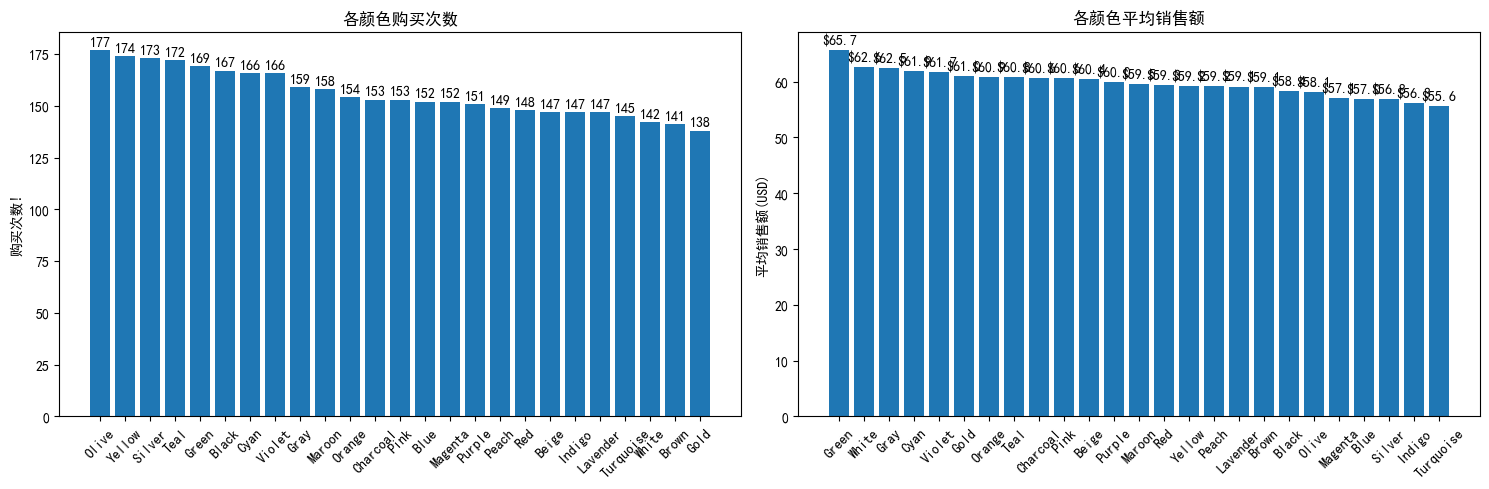

In [45]:
#绘制颜色做好分析图
plt.figure(figsize=(15, 5))

#子图1:各颜色购买次数
plt.subplot(1, 2, 1)
plt.bar (color_counts.index, color_counts.values)
plt.title('各颜色购买次数')
plt.xticks(rotation=45)
plt.ylabel('购买次数!')
#在柱状图上添加数值标签
for i, v in enumerate (color_counts.values):
    plt.text(i, v+2, str(v), ha='center'    )

#子图2:各颜色平均销售额
plt.subplot(1, 2, 2)
plt.bar(color_avg_sales.index, color_avg_sales.values)
plt.title('各颜色平均销售额')
plt.xticks(rotation=45)
plt.ylabel('平均销售额(USD)')
#在柱状图上添加数值标签
for i, v in enumerate (color_avg_sales.values):
    plt.text(i, v + 1, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.show()

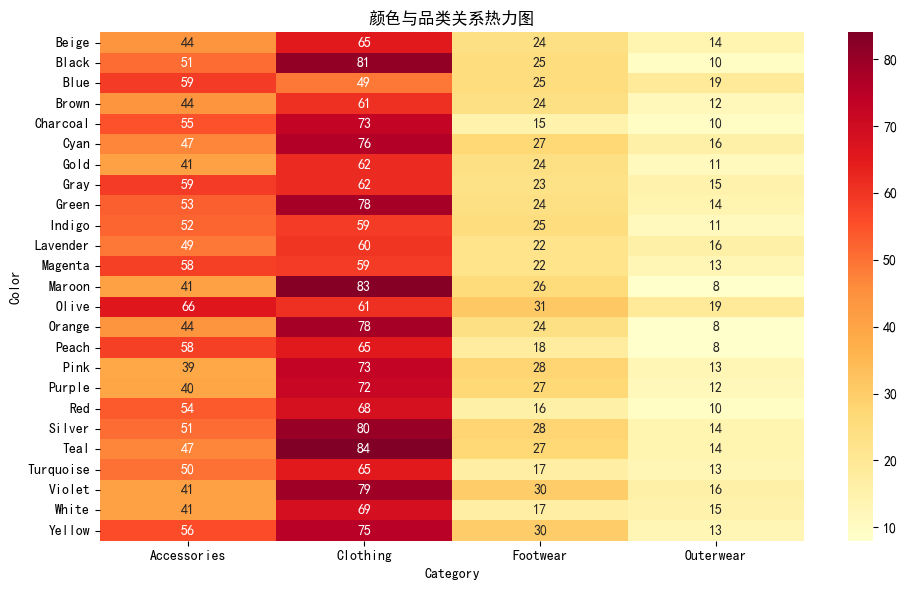

In [46]:
# 配色与品类的关系分析
color_category = pd.crosstab(data['Color'], data['Category'])

# 绘制热力图展示颜色与品类的关系
plt.figure(figsize=(10, 6))
sns.heatmap (color_category, annot = True, fmt='d', cmap='YlOrRd')
plt.title('颜色与品类关系热力图')
plt.tight_layout()
plt.show()